Error relativo RMS x medio [%]: 8.333921034213127
Error relativo RMS y medio [%]: 4.029016110229156
Error relativo N medio [%]: 25108814.619925484
Error relativo RMS x máximo [%]: 46.93864940695739
Error relativo RMS y máximo [%]: 60.848438600762535
Error relativo N máximo [%]: 25649806.6943734


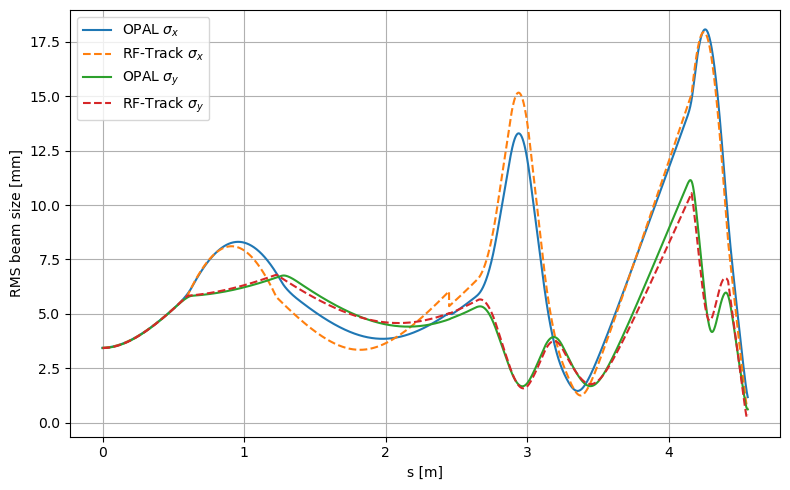

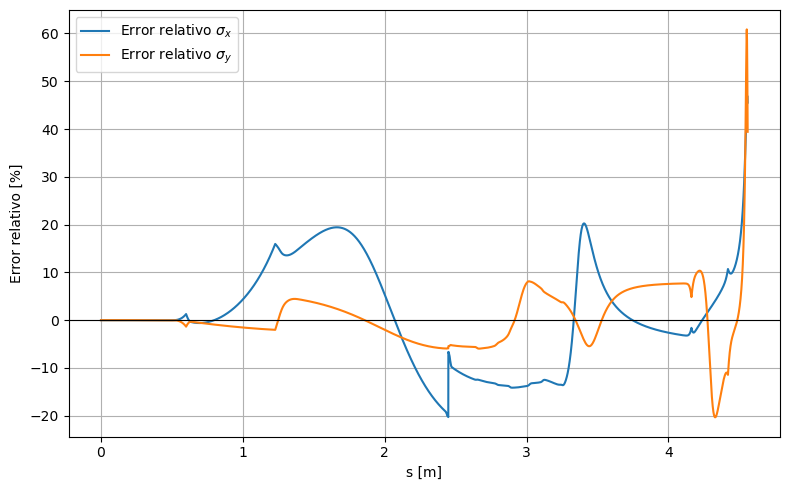

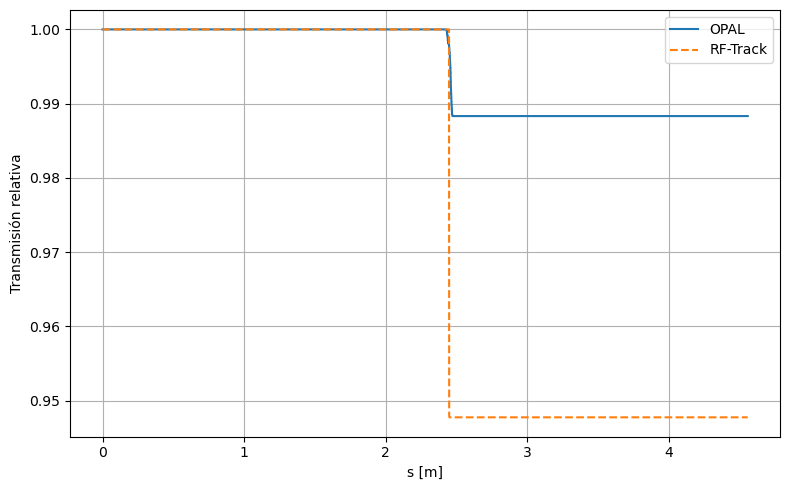

In [ ]:
from pathlib import Path 
import numpy as np 
import matplotlib.pyplot as plt 

root = Path.cwd()

opal_lebt = np.loadtxt(root / "opal" / "lebt.stat", skiprows=303)

s_opal = opal_lebt[:, 1]
rms_x_opal = opal_lebt[:, 5] * 1e3   
rms_y_opal = opal_lebt[:, 6] * 1e3
N_opal = opal_lebt[:, 2]

rftrack_lebt = np.loadtxt(root / "rftrack" / "rftrack_lebt_transport.txt", skiprows=1)

s_rf = rftrack_lebt[:, 0]
rms_x_rf = rftrack_lebt[:, 1]
rms_y_rf = rftrack_lebt[:, 2]
N_rf = rftrack_lebt[:, 3]


s_min = max(s_opal.min(), s_rf.min())
s_max = min(s_opal.max(), s_rf.max())

mask = (s_opal >= s_min) & (s_opal <= s_max)

s_common = s_opal[mask]
rms_x_opal_c = rms_x_opal[mask]
rms_y_opal_c = rms_y_opal[mask]
N_opal_c = N_opal[mask]


rms_x_rf_interp = np.interp(s_common, s_rf, rms_x_rf)
rms_y_rf_interp = np.interp(s_common, s_rf, rms_y_rf)
N_rf_interp = np.interp(s_common, s_rf, N_rf)

err_abs_x = rms_x_opal_c - rms_x_rf_interp
err_abs_y = rms_y_opal_c - rms_y_rf_interp
err_abs_N = N_opal_c - N_rf_interp

eps = 1e-12

err_rel_x = err_abs_x / (rms_x_opal_c + eps)
err_rel_y = err_abs_y / (rms_y_opal_c + eps)
err_rel_N = err_abs_N / (N_opal_c + eps)

err_rel_x_percent = 100 * err_rel_x
err_rel_y_percent = 100 * err_rel_y
err_rel_N_percent = 100 * err_rel_N

plt.figure(figsize=(8, 5))
plt.plot(s_common, rms_x_opal_c, label="OPAL $\\sigma_x$")
plt.plot(s_common, rms_x_rf_interp, "--", label="RF-Track $\\sigma_x$")
plt.plot(s_common, rms_y_opal_c, label="OPAL $\\sigma_y$")
plt.plot(s_common, rms_y_rf_interp, "--", label="RF-Track $\\sigma_y$")

plt.xlabel("s [m]")
plt.ylabel("RMS beam size [mm]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(s_common, err_rel_x_percent, label="Error relativo $\\sigma_x$")
plt.plot(s_common, err_rel_y_percent, label="Error relativo $\\sigma_y$")

plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("s [m]")
plt.ylabel("Error relativo [%]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(s_common, N_opal_c / N_opal_c[0], label="OPAL")
plt.plot(s_common, N_rf_interp / N_rf_interp[0], "--", label="RF-Track")

plt.xlabel("s [m]")
plt.ylabel("Transmisión relativa")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()